# Setup

In [1]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

# single cell
import anndata as ad
import scanpy as sc

# custom
sys.path.insert(0, '../../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

CORES = 10
DATADIR = Path("../../../../data") / "processed" / "single_cell" / "combined"
REFDIR = Path("../../../../references")
SUBSETS_DIR = DATADIR / "subsets"

METADATA = [
    "Diet",
    "Age",
    "Depot",
    "Sex",
]
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
GLOBAL_INT_KEY = "global_INT_scvi-hvg-Identifier"

%load_ext autoreload
%load_ext rpy2.ipython
%matplotlib inline
converter = get_converter()
# R_preload()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_info/main.py:213: DeprecationWarning: Accessing jsonschema.__version__ is deprecated and will be removed in a future release. Use importlib.metadata directly to query for jsonschema's version.
/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/session_in

# Subset mac/fib pops

In [22]:
adata_fibro = sc.read_h5ad(SUBSETS_DIR / "fibro.h5ad")
adata_macro = sc.read_h5ad(SUBSETS_DIR / "macro.h5ad")
adata = sc.read_h5ad(DATADIR / "eWAT_Male.h5ad")

In [65]:
filtered = adata_fibro.obs_names.tolist() + adata_macro.obs_names.tolist()
assert sum(adata.obs_names.isin(filtered)) == len(filtered)
adata = adata[filtered]

In [66]:
adata.obs["celltype_hires"] = None
adata.obs.loc[adata_fibro.obs_names.tolist(), "celltype_hires"] = "fibro_" + adata_fibro.obs["leiden_fibro_0.6"].astype(str)
adata.obs.loc[adata_macro.obs_names.tolist(), "celltype_hires"] = "macro_" + adata_macro.obs["leiden_macro_0.3"].astype(str)
order_obs(adata, "celltype_hires", np.sort(adata.obs["celltype_hires"].unique()))

In [68]:
adata.write(DATADIR / "eWAT_Male-fb_macs.h5ad")

# Liana Aggregate Data

In [2]:
adata = sc.read_h5ad(DATADIR / "eWAT_Male-fb_macs.h5ad")

In [ ]:
import omnipath as op
args = {'sources': 'resource_specific', 'scope': 'generic', 'genesymbols' : True, 'organisms' : 'mouse'}
lig_rec = op.interactions.import_intercell_network(
    include = ['omnipath', 'ligrecextra'],
    transmitter_params = {'parent': 'ligand'} | args,
    receiver_params = {'parent': 'receptor'} | args,
)
curated_resources = ['Guide2Pharma', 'HPMR', 'ICELLNET', 'Kirouac2010',
        'CellTalkDB', 'CellChatDB', 'connectomeDB2020', 'CellPhoneDB', 'Cellinker', 'talklr', 'SignaLink3']
pattern = '|'.join(curated_resources)
filtered_lig_rec = lig_rec[lig_rec['sources'].str.contains(pattern, case=False, na=False)].reset_index(drop=True)
filtered_lig_rec = filtered_lig_rec[filtered_lig_rec["curation_effort"] < 3]
# ccc_db_op = op.interactions.OmniPath.get(genesymbols = True, organisms="mouse")
# ccc_db_op = ccc_db_op.rename(columns={"source" : "ligand", "target" : "receptor"})
# op.interactions.AllInteractions.get().to_csv(REFDIR / "omnipath_all.csv")

In [ ]:
df = op.interactions.OmniPath.get(organisms="mouse", genesymbols=True)
df["references"]

Index(['source', 'target', 'source_genesymbol', 'target_genesymbol',
       'is_directed', 'is_stimulation', 'is_inhibition', 'consensus_direction',
       'consensus_stimulation', 'consensus_inhibition', 'curation_effort',
       'references', 'sources', 'n_sources', 'n_primary_sources',
       'n_references', 'references_stripped'],
      dtype='object')

In [69]:
import omnipath as op
ccc_db = pd.read_csv(REFDIR / "ethan_ccc_database.csv")
ccc_db['receptor'] = (
    ccc_db['receptor']
      .str.split(r'[\|,;/+&_]')   # adjust delimiters if needed
)
ccc_db = ccc_db.explode('receptor', ignore_index=True)
ccc_db = ccc_db.drop_duplicates(subset=['ligand', 'receptor'], keep='first').reset_index(drop=True)

In [71]:
# ligand-receptor pairs
cell2cell_interactions(adata, "celltype_hires", ccc_db, cores=CORES)

# for cond in adata.obs["Diet"].cat.categories:
#     tmp = adata[adata.obs["Diet"] == cond]
#     cell2cell_interactions(tmp, "celltype_hires", ccc_db, cores=CORES)
#     adata.uns[f"ccc_filtered_{cond}"] = tmp.uns["ccc_filtered"]

adata

Using provided `resource`.


Generating ligand-receptor stats for 100798 samples and 2021 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:39<00:00, 25.09it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


AnnData object with n_obs × n_vars = 100798 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown', 'celltype_hires'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_v

In [5]:
celltypes = adata.obs["celltype_hires"].cat.categories
fibros = celltypes[celltypes.str.contains("fibro")].tolist()
macros = celltypes[celltypes.str.contains("macro")].tolist()

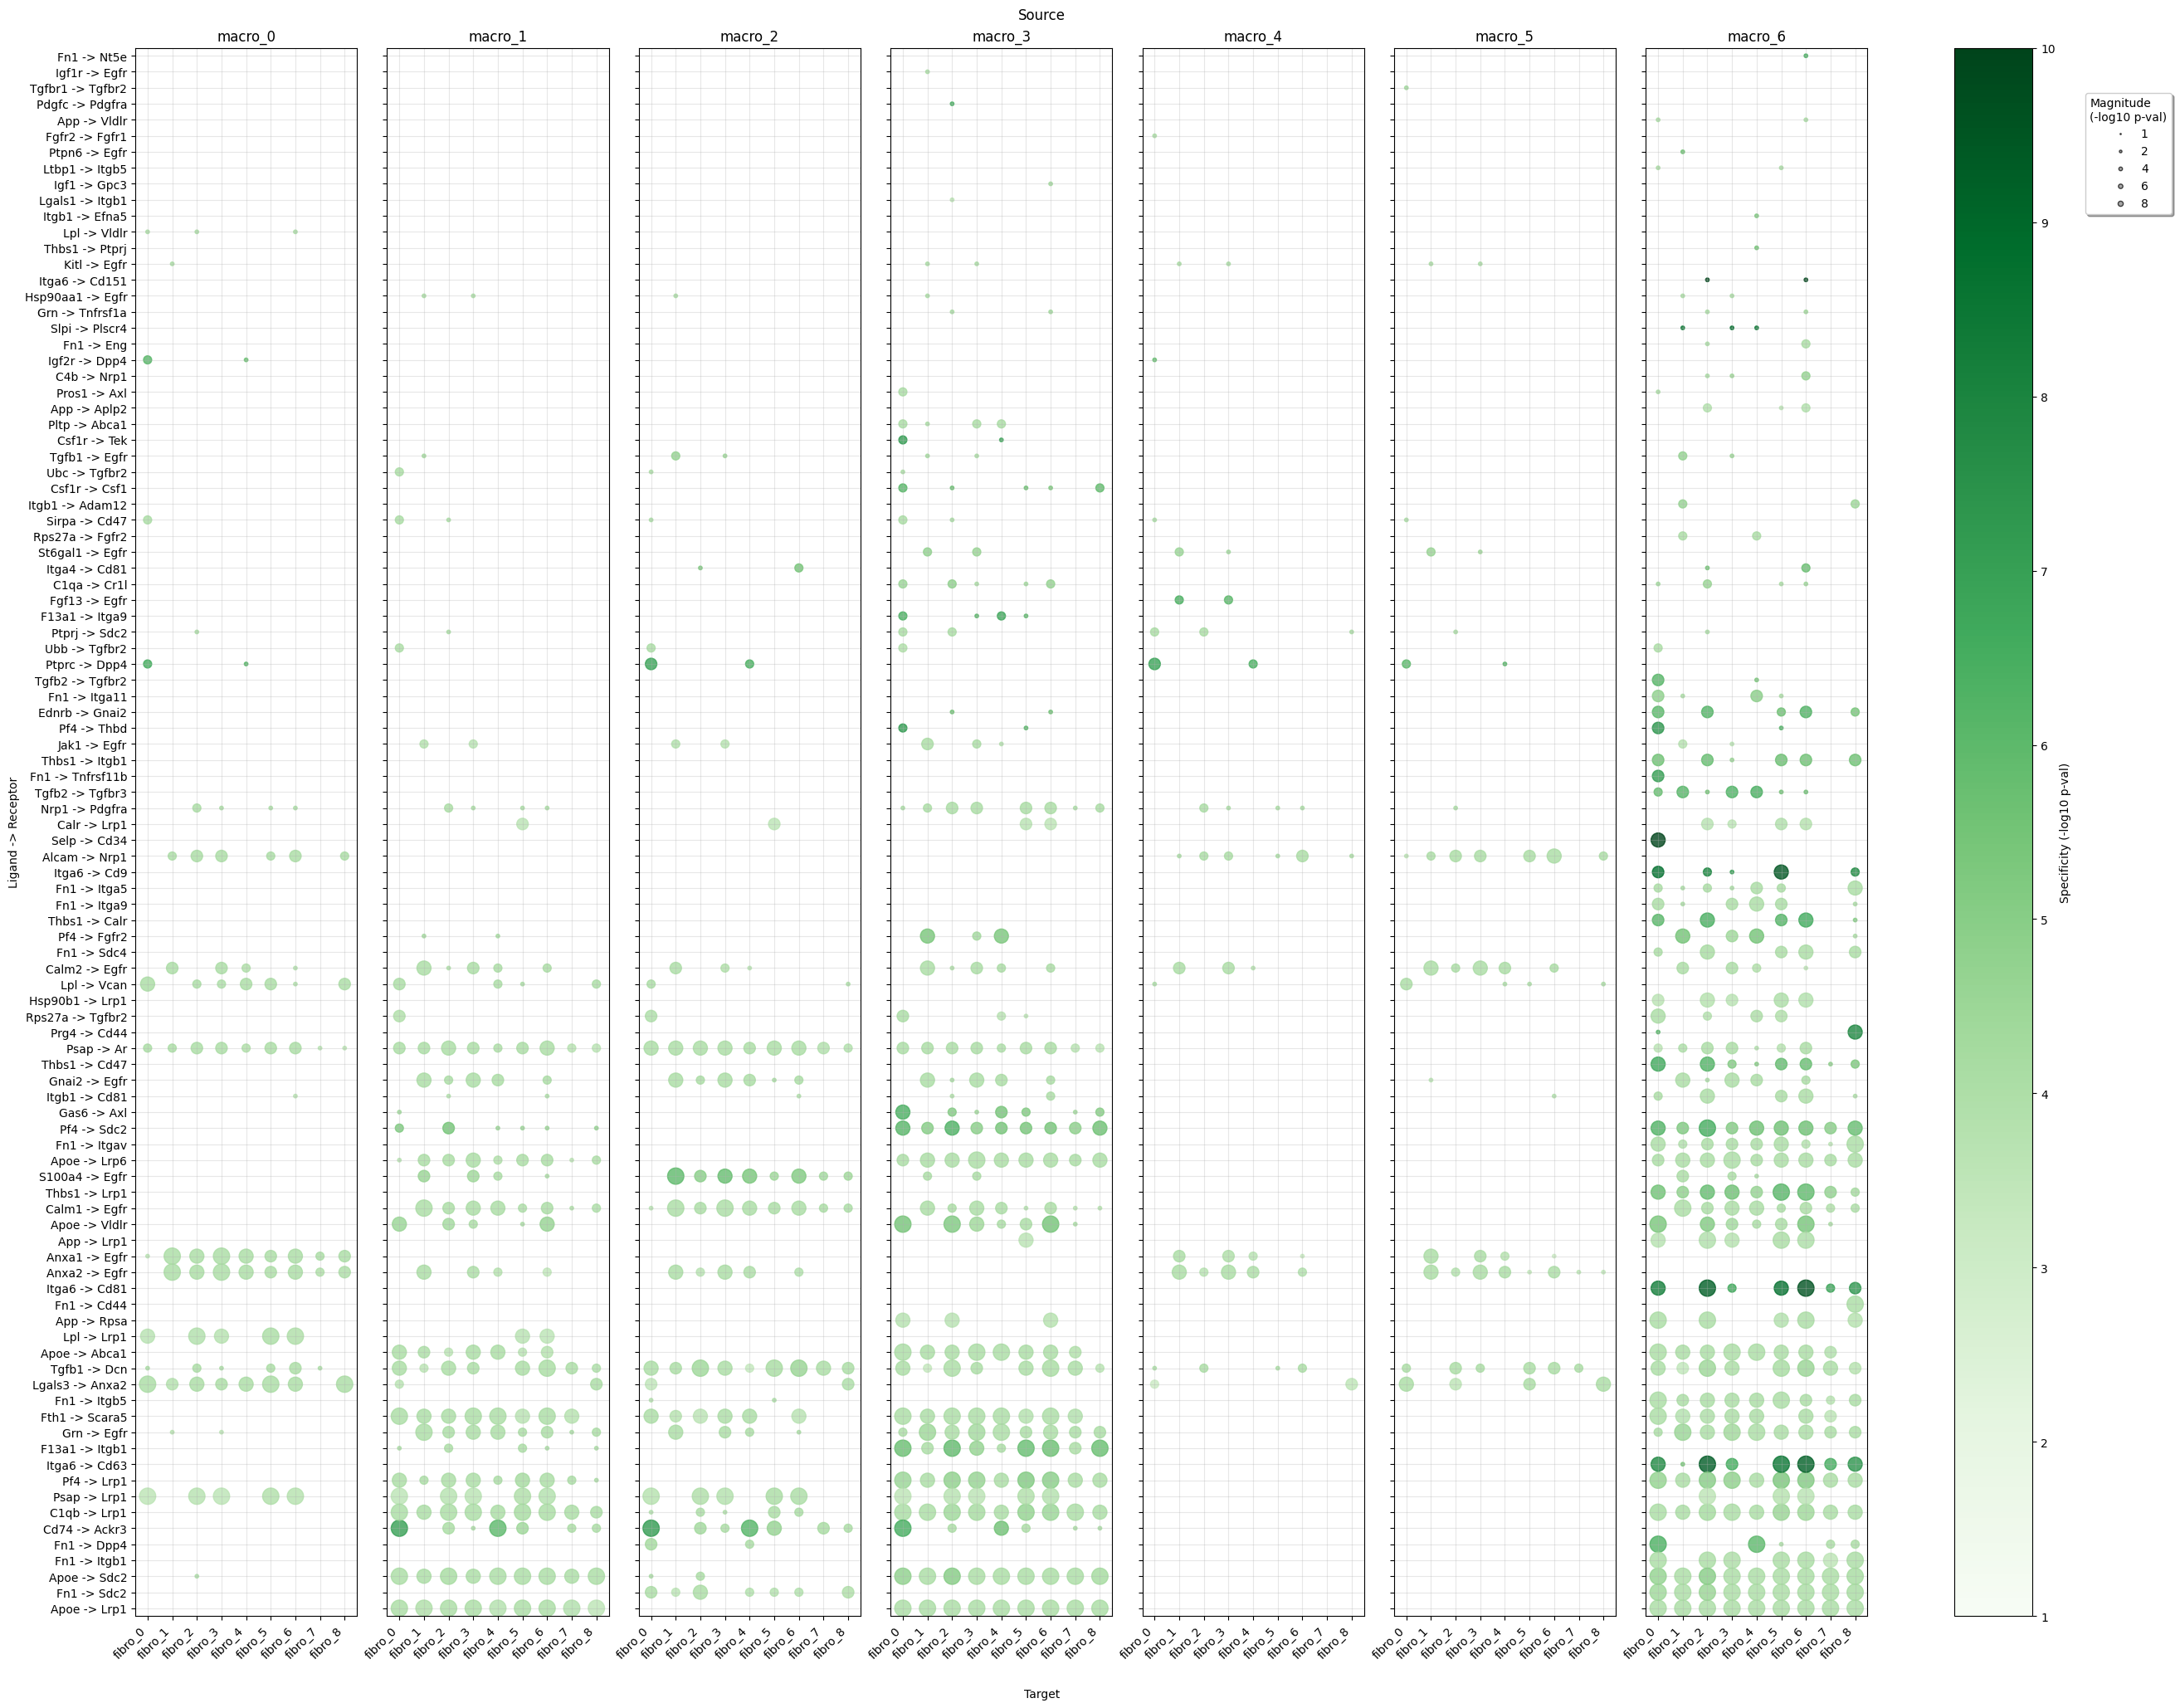

In [137]:

def plot_c2c(
    adata: sc.AnnData,
    key: str,
    pval: float = 0.05,
    top_n: int = 20,
    sources: Iterable[str] = None,
    targets: Iterable[str] = None,
    includes_genes: Iterable[str] = None,
    figsize=(15, 8),
):
    """Lightweight cell-cell communication dotplot with controlled dot sizes."""

    df = adata.uns[key]
    df = df[df["magnitude_rank"] < pval]

    if sources:
        df = df[df["source"].isin(sources)]
    if targets:
        df = df[df["target"].isin(targets)]
    if includes_genes:
        df = df[df["ligand_complex"].isin(includes_genes) | df["receptor_complex"].isin(includes_genes)]

    df = df.nsmallest(top_n, "magnitude_rank")

    # Use complex columns if available, fallback to simple
    lig_col = "ligand_complex" if "ligand_complex" in df.columns else "ligand"
    rec_col = "receptor_complex" if "receptor_complex" in df.columns else "receptor"
    df["lr"] = df[lig_col] + " -> " + df[rec_col]

    # Efficient size mapping: 5 quantile-based bins, min size 10
    mag_vals = -np.log10(np.maximum(df["magnitude_rank"], 1e-10))
    size_bins = np.array([10, 50, 100, 150, 200])
    # Use 1 as minimum, then map higher values to larger sizes
    plt.Normalize(vmin=1, vmax=mag_vals.max())
    df["dot_size"] = size_bins[
        np.searchsorted(
            np.percentile(mag_vals, [20, 40, 60, 80]), np.maximum(mag_vals, 1)
        )
    ]

    src_list = sorted(df["source"].unique())
    tgt_list = sorted(df["target"].unique())
    lr_list = df["lr"].drop_duplicates().tolist()

    fig, axes = plt.subplots(
        1, len(src_list), figsize=figsize, sharey=True, layout="constrained"
    )
    if len(src_list) == 1:
        axes = [axes]

    # Pre-compute color normalization
    spec_vals = -np.log10(np.maximum(df["specificity_rank"], 1e-10))
    norm = plt.Normalize(vmin=1, vmax=spec_vals.max())

    for i, src in enumerate(src_list):
        ax = axes[i]
        data = df[df["source"] == src]

        if len(data):
            x = [tgt_list.index(t) for t in data["target"]]
            y = [lr_list.index(lr) for lr in data["lr"]]
            colors = plt.cm.Greens(
                norm(-np.log10(np.maximum(data["specificity_rank"], 1e-10)))
            )
            ax.scatter(
                x, y, c=colors, s=data["dot_size"], alpha=0.8, edgecolors=colors, lw=1
            )

        ax.set(
            xlim=(-0.5, len(tgt_list) - 0.5),
            ylim=(-0.5, len(lr_list) - 0.5),
            xticks=range(len(tgt_list)),
            title=src,
        )
        ax.set_xticklabels(tgt_list, rotation=45, ha="right")
        ax.grid(alpha=0.3)

    axes[0].set(yticks=range(len(lr_list)), ylabel="Ligand -> Receptor")
    axes[0].set_yticklabels(lr_list)
    fig.suptitle("Source")
    fig.text(0.5, -0.02, "Target", ha="center")

    fig.subplots_adjust(right=0.75)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)
    plt.colorbar(sm, ax=axes, label="Specificity (-log10 p-val)")

    # Create proper size legend using evenly spaced integer values
    if len(mag_vals) > 0:  # Only create legend if we have data
        max_val = int(np.ceil(mag_vals.max()))
        if max_val <= 1:
            size_labels = ["1"]
        else:
            thresholds = np.linspace(1, max_val, 5).astype(int)
            thresholds = np.array(sorted(set(thresholds)))
            size_labels = [str(t) for t in thresholds]

        # Create legend elements
        from matplotlib.lines import Line2D

        legend_elements = []
        for i, label in enumerate(size_labels):
            if i < len(size_bins):
                size = size_bins[i]
                legend_elements.append(
                    Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="gray",
                        markersize=np.sqrt(size / 10),
                        alpha=0.7,
                        markeredgecolor="k",
                        label=label,
                    )
                )

        # Add legend to the figure
        fig.legend(
            handles=legend_elements,
            title="Magnitude\n(-log10 p-val)",
            loc="upper left",
            frameon=True,
            bbox_to_anchor=(1, 0.95),
            fancybox=True,
            shadow=True,
        )

    return



plot_c2c(
    adata, "ccc_filtered", top_n = 1000,
    sources=macros, targets=fibros,
    figsize=(25,20))

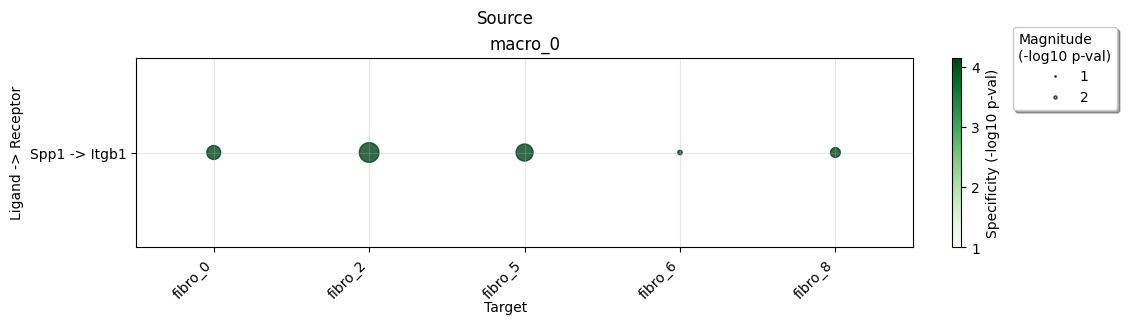

In [16]:

def plot_c2c(
    adata: sc.AnnData,
    key: str,
    pval: float = 0.05,
    top_n: int = 20,
    sources: Iterable[str] = None,
    targets: Iterable[str] = None,
    includes_genes: Iterable[str] = None,
    figsize=(15, 8),
):
    """Lightweight cell-cell communication dotplot with controlled dot sizes."""

    df = adata.uns[key]
    df = df[df["magnitude_rank"] < pval]

    if sources:
        df = df[df["source"].isin(sources)]
    if targets:
        df = df[df["target"].isin(targets)]
    if includes_genes:
        df = df[df["ligand_complex"].isin(includes_genes) | df["receptor_complex"].isin(includes_genes)]

    df = df.nsmallest(top_n, "magnitude_rank")

    # Use complex columns if available, fallback to simple
    lig_col = "ligand_complex" if "ligand_complex" in df.columns else "ligand"
    rec_col = "receptor_complex" if "receptor_complex" in df.columns else "receptor"
    df["lr"] = df[lig_col] + " -> " + df[rec_col]

    # Efficient size mapping: 5 quantile-based bins, min size 10
    mag_vals = -np.log10(np.maximum(df["magnitude_rank"], 1e-10))
    size_bins = np.array([10, 50, 100, 150, 200])
    # Use 1 as minimum, then map higher values to larger sizes
    plt.Normalize(vmin=1, vmax=mag_vals.max())
    df["dot_size"] = size_bins[
        np.searchsorted(
            np.percentile(mag_vals, [20, 40, 60, 80]), np.maximum(mag_vals, 1)
        )
    ]

    src_list = sorted(df["source"].unique())
    tgt_list = sorted(df["target"].unique())
    lr_list = df["lr"].drop_duplicates().tolist()

    fig, axes = plt.subplots(
        1, len(src_list), figsize=figsize, sharey=True, layout="constrained"
    )
    if len(src_list) == 1:
        axes = [axes]

    # Pre-compute color normalization
    spec_vals = -np.log10(np.maximum(df["specificity_rank"], 1e-10))
    norm = plt.Normalize(vmin=1, vmax=spec_vals.max())

    for i, src in enumerate(src_list):
        ax = axes[i]
        data = df[df["source"] == src]

        if len(data):
            x = [tgt_list.index(t) for t in data["target"]]
            y = [lr_list.index(lr) for lr in data["lr"]]
            colors = plt.cm.Greens(
                norm(-np.log10(np.maximum(data["specificity_rank"], 1e-10)))
            )
            ax.scatter(
                x, y, c=colors, s=data["dot_size"], alpha=0.8, edgecolors=colors, lw=1
            )

        ax.set(
            xlim=(-0.5, len(tgt_list) - 0.5),
            ylim=(-0.5, len(lr_list) - 0.5),
            xticks=range(len(tgt_list)),
            title=src,
        )
        ax.set_xticklabels(tgt_list, rotation=45, ha="right")
        ax.grid(alpha=0.3)

    axes[0].set(yticks=range(len(lr_list)), ylabel="Ligand -> Receptor")
    axes[0].set_yticklabels(lr_list)
    fig.suptitle("Source")
    fig.text(0.5, -0.02, "Target", ha="center")

    fig.subplots_adjust(right=0.75)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap="Greens", norm=norm)
    plt.colorbar(sm, ax=axes, label="Specificity (-log10 p-val)")

    # Create proper size legend using evenly spaced integer values
    if len(mag_vals) > 0:  # Only create legend if we have data
        max_val = int(np.ceil(mag_vals.max()))
        if max_val <= 1:
            size_labels = ["1"]
        else:
            thresholds = np.linspace(1, max_val, 5).astype(int)
            thresholds = np.array(sorted(set(thresholds)))
            size_labels = [str(t) for t in thresholds]

        # Create legend elements
        from matplotlib.lines import Line2D

        legend_elements = []
        for i, label in enumerate(size_labels):
            if i < len(size_bins):
                size = size_bins[i]
                legend_elements.append(
                    Line2D(
                        [0],
                        [0],
                        marker="o",
                        color="w",
                        markerfacecolor="gray",
                        markersize=np.sqrt(size / 10),
                        alpha=0.7,
                        markeredgecolor="k",
                        label=label,
                    )
                )

        # Add legend to the figure
        fig.legend(
            handles=legend_elements,
            title="Magnitude\n(-log10 p-val)",
            loc="upper left",
            frameon=True,
            bbox_to_anchor=(1, 0.95),
            fancybox=True,
            shadow=True,
        )

    return

plot_c2c(
    adata, "ccc", pval=0.1, top_n = 200,
    includes_genes=["Spp1"],
    targets=fibros,
    figsize=(10,3))

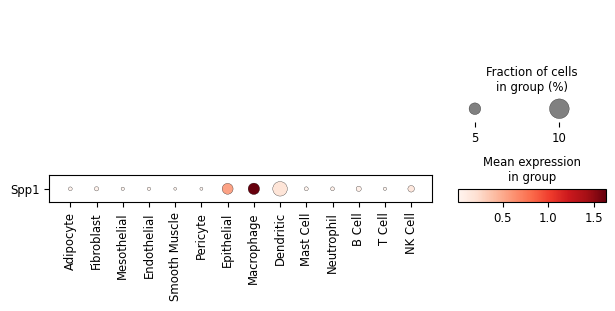

In [23]:
# sc.pl.dotplot(adata, "Spp1", "celltype_hires", swap_axes=True)
sc.pl.dotplot(adata, "Spp1", "celltype", swap_axes=True)

In [ ]:
adata.write(DATADIR / "eWAT_Male-fb_macs.h5ad")

# MOFA
see [liana tutorial](https://liana-py.readthedocs.io/en/latest/notebooks/mofacellular.html#fitting-a-mofa-model)